## **Agricultural Yield Intelligence System using Machine Learning**

# Problem Statement:

Agricultural productivity, especially paddy cultivation, is highly influenced by multiple environmental and agronomic factors such as rainfall, temperature, humidity, soil type, nursery conditions, and wind parameters. However, predicting crop yield levels in advance remains a major challenge due to the complex interaction of these variables.

# Goal :
The objective of this project is to develop a **machine learning model** that predicts the actual paddy yield (in kilograms) using historical agronomic and climatic data. The model aims to assist farmers, agricultural planners, and policymakers in making informed decisions related to irrigation planning, fertilizer usage, and resource allocation.

# Import required libraries

In [1]:
import numpy as np
import pandas as pd
import warnings 
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt 
import seaborn as sns

# Load the dataset

In [2]:
df = pd.read_csv("paddydataset.csv")
df.head()

,Hectares,Agriblock,Variety,Soil Types,Seedrate(in Kg),LP_Mainfield(in Tonnes),Nursery,Nursery area (Cents),LP_nurseryarea(in Tonnes),DAP_20days,...,Wind Direction_D1_D30,Wind Direction_D31_D60,Wind Direction_D61_D90,Wind Direction_D91_D120,Relative Humidity_D1_D30,Relative Humidity_D31_D60,Relative Humidity_D61_D90,Relative Humidity_D91_D120,Trash(in bundles),Paddy yield(in Kg)
0,6,Cuddalore,CO_43,alluvial,150,75.0,dry,120,6,240,...,SW,W,NNW,WSW,72.0,78,88,85,540,35028
1,6,Kurinjipadi,ponmani,clay,150,75.0,wet,120,6,240,...,NW,S,SE,SSE,64.6,85,84,87,600,35412
2,6,Panruti,delux ponni,alluvial,150,75.0,dry,120,6,240,...,ENE,NE,NNE,W,85.0,96,84,79,600,36300
3,6,Kallakurichi,CO_43,clay,150,75.0,wet,120,6,240,...,W,WNW,SE,S,88.5,95,81,84,540,35016
4,6,Sankarapuram,ponmani,alluvial,150,75.0,dry,120,6,240,...,SSE,W,SW,NW,72.7,91,83,81,600,34044


# Dataset Description

This dataset contains agricultural records of paddy cultivation collected across multiple regions.

## Target Variable:
| Column | Description |
|---|---|
| Paddy_yield_in_Kg | Total paddy yield in kilograms — this is what we predict |

## Field & Agronomic Features:
| Column | Description |
|---|---|
| Hectares | Total land area cultivated (in hectares) |
| Agriblock | Agricultural block / region name |
| Variety | Paddy variety used (e.g., CO_43, ponmani, delux ponni) |
| Soil_Types | Type of soil (alluvial, clay, loamy, etc.) |
| Seedrate_in_Kg | Amount of seed used per hectare |
| Nursery | Nursery method used (dry / wet) |
| DAP_20days | Di-ammonium phosphate fertilizer applied at 20 days |
| Urea_40Days | Urea fertilizer applied at 40 days |
| Potash_50Days | Potash fertilizer applied at 50 days |
| Pest_60Day_in_ml | Pesticide applied at 60 days (in ml) |
| Weed28D_thiobencarb | Weedicide applied at 28 days |
| Micronutrients_70Days | Micronutrients applied at 70 days |
| Trash_in_bundles | Crop residue/trash in bundles |

## Weather Features (measured across 4 growth intervals: D1-D30, D31-D60, D61-D90, D91-D120):
| Column | Description |
|---|---|
| 30DRain__in_mm | Rainfall in mm during each 30-day interval |
| Max_temp / Min_temp | Maximum and minimum temperature during each interval |
| Wind_Speed | Wind speed during each interval |
| Wind_Direction | Wind direction during each interval |
| Relative_Humidity | Relative humidity (%) during each interval |

## Dataset Size:
- Rows: ~1000+ records
- Columns: 40+ features
- Source: Agricultural field data from Tamil Nadu, India


# Understanding Dataset

In [3]:
df.shape

(2789, 45)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2789 entries, 0 to 2788
Data columns (total 45 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Hectares                            2789 non-null   int64  
 1   Agriblock                           2789 non-null   object 
 2   Variety                             2789 non-null   object 
 3   Soil Types                          2789 non-null   object 
 4   Seedrate(in Kg)                     2789 non-null   int64  
 5   LP_Mainfield(in Tonnes)             2789 non-null   float64
 6   Nursery                             2789 non-null   object 
 7   Nursery area (Cents)                2789 non-null   int64  
 8   LP_nurseryarea(in Tonnes)           2789 non-null   int64  
 9   DAP_20days                          2789 non-null   int64  
 10  Weed28D_thiobencarb                 2789 non-null   int64  
 11  Urea_40Days                         2789 no

In [5]:
df.describe()

,Hectares,Seedrate(in Kg),LP_Mainfield(in Tonnes),Nursery area (Cents),LP_nurseryarea(in Tonnes),DAP_20days,Weed28D_thiobencarb,Urea_40Days,Potassh_50Days,Micronutrients_70Days,...,Inst Wind Speed_D1_D30(in Knots),Inst Wind Speed_D31_D60(in Knots),Inst Wind Speed_D61_D90(in Knots),Inst Wind Speed_D91_D120(in Knots),Relative Humidity_D1_D30,Relative Humidity_D31_D60,Relative Humidity_D61_D90,Relative Humidity_D91_D120,Trash(in bundles),Paddy yield(in Kg)
count,2789.000000,2789.000000,2789.000000,2789.000000,2789.000000,2789.000000,2789.000000,2789.000000,2789.000000,2789.000000,...,2789.000000,2789.000000,2789.000000,2789.000000,2789.000000,2789.000000,2789.000000,2789.000000,2789.000000,2789.000000
mean,3.717461,92.936536,46.468268,74.349229,3.717461,148.698458,7.434923,100.854729,38.587250,55.761922,...,7.233417,8.512729,8.172822,9.449265,76.256938,87.594120,85.160272,83.859448,335.510936,22517.728935
std,1.437777,35.944420,17.972210,28.755536,1.437777,57.511072,2.875554,39.006885,14.924123,21.566652,...,2.566549,3.203679,1.993596,2.516664,8.001361,6.776736,3.492529,3.134875,134.314772,9199.661393
min,1.000000,25.000000,12.500000,20.000000,1.000000,40.000000,2.000000,27.130000,10.380000,15.000000,...,4.000000,4.000000,4.000000,6.000000,64.600000,78.000000,81.000000,79.000000,80.000000,5410.000000
25%,3.000000,75.000000,37.500000,60.000000,3.000000,120.000000,6.000000,81.390000,31.140000,45.000000,...,4.000000,6.000000,8.000000,6.000000,72.000000,80.000000,83.000000,81.000000,240.000000,16389.000000
50%,4.000000,100.000000,50.000000,80.000000,4.000000,160.000000,8.000000,108.520000,41.520000,60.000000,...,8.000000,10.000000,8.000000,10.000000,72.700000,91.000000,84.000000,84.000000,360.000000,24636.000000
75%,5.000000,125.000000,62.500000,100.000000,5.000000,200.000000,10.000000,135.650000,51.900000,75.000000,...,10.000000,12.000000,10.000000,12.000000,85.000000,95.000000,88.000000,87.000000,450.000000,31035.000000
max,6.000000,150.000000,75.000000,120.000000,6.000000,240.000000,12.000000,162.780000,62.280000,90.000000,...,10.000000,12.000000,10.000000,12.000000,88.500000,96.000000,92.000000,88.000000,600.000000,38814.000000


In [6]:
df.columns

Index(['Hectares ', 'Agriblock', 'Variety', 'Soil Types', 'Seedrate(in Kg)',
       'LP_Mainfield(in Tonnes)', 'Nursery', 'Nursery area (Cents)',
       'LP_nurseryarea(in Tonnes)', 'DAP_20days', 'Weed28D_thiobencarb',
       'Urea_40Days', 'Potassh_50Days', 'Micronutrients_70Days',
       'Pest_60Day(in ml)', '30DRain( in mm)', '30DAI(in mm)',
       '30_50DRain( in mm)', '30_50DAI(in mm)', '51_70DRain(in mm)',
       '51_70AI(in mm)', '71_105DRain(in mm)', '71_105DAI(in mm)',
       'Min temp_D1_D30', 'Max temp_D1_D30', 'Min temp_D31_D60',
       'Max temp_D31_D60', 'Min temp_D61_D90', 'Max temp_D61_D90',
       'Min temp_D91_D120', 'Max temp_D91_D120',
       'Inst Wind Speed_D1_D30(in Knots)', 'Inst Wind Speed_D31_D60(in Knots)',
       'Inst Wind Speed_D61_D90(in Knots)',
       'Inst Wind Speed_D91_D120(in Knots)', 'Wind Direction_D1_D30',
       'Wind Direction_D31_D60', 'Wind Direction_D61_D90',
       'Wind Direction_D91_D120', 'Relative Humidity_D1_D30',
       'Relative Humi

# Clean Column Names
- Step 1: Remove trailing spaces + special characters
- Step 2: Convert to lowercase

In [7]:
df.columns = df.columns.str.strip()  # remove leading/trailing spaces
df.columns = df.columns.str.replace(' ', '_')
df.columns = df.columns.str.replace('(', '_', regex=False)
df.columns = df.columns.str.replace(')', '', regex=False)
df.columns = df.columns.str.replace('/', '_')
df.columns = df.columns.str.replace('-', '_')

# Checking Null Values & Duplicate Rows

In [8]:
df.isnull().sum()

Hectares                             0
Agriblock                            0
Variety                              0
Soil_Types                           0
Seedrate_in_Kg                       0
LP_Mainfield_in_Tonnes               0
Nursery                              0
Nursery_area__Cents                  0
LP_nurseryarea_in_Tonnes             0
DAP_20days                           0
Weed28D_thiobencarb                  0
Urea_40Days                          0
Potassh_50Days                       0
Micronutrients_70Days                0
Pest_60Day_in_ml                     0
30DRain__in_mm                       0
30DAI_in_mm                          0
30_50DRain__in_mm                    0
30_50DAI_in_mm                       0
51_70DRain_in_mm                     0
51_70AI_in_mm                        0
71_105DRain_in_mm                    0
71_105DAI_in_mm                      0
Min_temp_D1_D30                      0
Max_temp_D1_D30                      0
Min_temp_D31_D60         

In [9]:
df.duplicated().sum()

451

- **Dropping Duplicated rows**

In [10]:
df = df.drop_duplicates()
df.shape

(2338, 45)

# Detecting Outliers

In [11]:
num_cols = df.select_dtypes(include =['int64','float64']).columns
cat_cols = df.select_dtypes(include='object').columns

In [12]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    print(f"Lower_limit: {lower_limit}")
    print(f"Upper_limit: {upper_limit}")
    print("Max:", df[col].max())
    print("Min:", df[col].min())

    outliers = df[(df[col] < lower_limit) | (df[col] > upper_limit)]
    print(f"Outliers Count of {col}:", outliers.shape[0])
    print("-"*40)

Lower_limit: 0.0
Upper_limit: 8.0
Max: 6
Min: 1
Outliers Count of Hectares: 0
----------------------------------------
Lower_limit: 0.0
Upper_limit: 200.0
Max: 150
Min: 25
Outliers Count of Seedrate_in_Kg: 0
----------------------------------------
Lower_limit: 0.0
Upper_limit: 100.0
Max: 75.0
Min: 12.5
Outliers Count of LP_Mainfield_in_Tonnes: 0
----------------------------------------
Lower_limit: 0.0
Upper_limit: 160.0
Max: 120
Min: 20
Outliers Count of Nursery_area__Cents: 0
----------------------------------------
Lower_limit: 0.0
Upper_limit: 8.0
Max: 6
Min: 1
Outliers Count of LP_nurseryarea_in_Tonnes: 0
----------------------------------------
Lower_limit: 0.0
Upper_limit: 320.0
Max: 240
Min: 40
Outliers Count of DAP_20days: 0
----------------------------------------
Lower_limit: 0.0
Upper_limit: 16.0
Max: 12
Min: 2
Outliers Count of Weed28D_thiobencarb: 0
----------------------------------------
Lower_limit: -1.4210854715202004e-14
Upper_limit: 217.04000000000002
Max: 162.78
M

# **EDA**

# Target Variable Distribution

<Figure size 800x400 with 0 Axes>

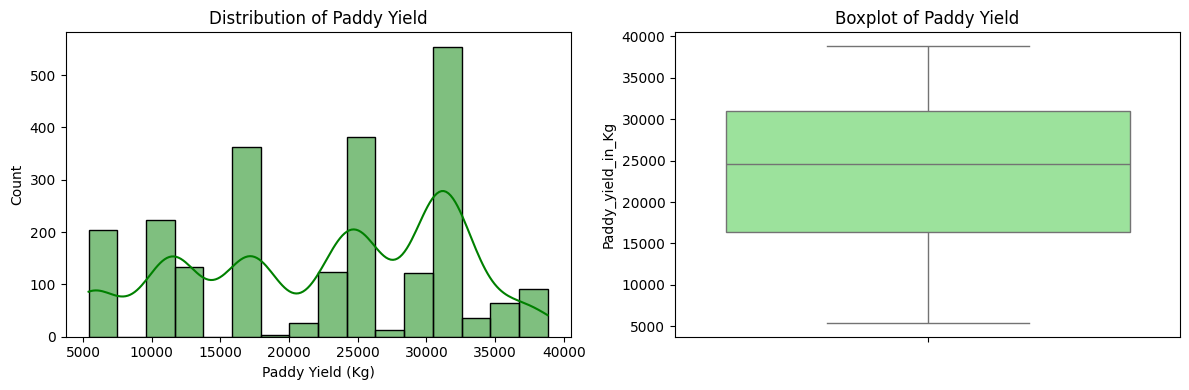

In [13]:
# Target Variable Distribution
plt.figure(figsize=(8, 4))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram + KDE
sns.histplot(df['Paddy_yield_in_Kg'], kde=True, ax=axes[0], color='green')
axes[0].set_title("Distribution of Paddy Yield")
axes[0].set_xlabel("Paddy Yield (Kg)")

# Boxplot
sns.boxplot(y=df['Paddy_yield_in_Kg'], ax=axes[1], color='lightgreen')
axes[1].set_title("Boxplot of Paddy Yield")

plt.tight_layout()
plt.show()

**Interpretation:**
- The distribution of Paddy Yield is **right-skewed** — most farms produce between 
  15,000–35,000 Kg, with a peak around 30,000–35,000 Kg.
- The boxplot shows the **median yield is around 25,000 Kg**.
- The long lower whisker indicates some farms have very low yield (5,000 Kg), 
  likely due to poor soil, less land, or adverse weather.
- No extreme outliers visible — data is relatively clean for the target variable.

#  Skewness of All Numerical Columns

In [14]:
# Skewness Check
skewness = df[num_cols].skew().sort_values(ascending=False)
print("Skewness of Numerical Columns:")
print(skewness)

Skewness of Numerical Columns:
Relative_Humidity_D61_D90            0.869560
Min_temp_D91_D120                    0.824008
71_105DRain_in_mm                    0.619559
30_50DRain__in_mm                    0.619559
30DRain__in_mm                       0.538152
Max_temp_D91_D120                    0.169035
Max_temp_D31_D60                     0.157000
Relative_Humidity_D1_D30             0.124985
51_70DRain_in_mm                     0.041719
51_70AI_in_mm                       -0.041719
Min_temp_D1_D30                     -0.098524
Inst_Wind_Speed_D31_D60_in_Knots    -0.115975
Inst_Wind_Speed_D1_D30_in_Knots     -0.144067
Relative_Humidity_D31_D60           -0.167340
Trash_in_bundles                    -0.196546
Max_temp_D1_D30                     -0.207991
Relative_Humidity_D91_D120          -0.209983
Max_temp_D61_D90                    -0.294760
Min_temp_D31_D60                    -0.309515
Min_temp_D61_D90                    -0.313655
Paddy_yield_in_Kg                   -0.316868
Pot

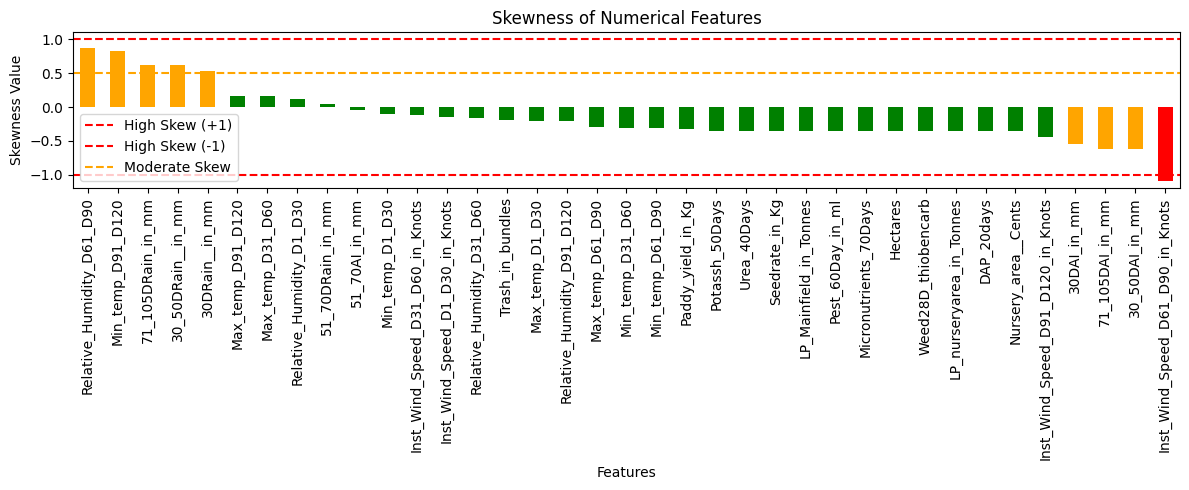

In [15]:
# Skewness Bar Chart
plt.figure(figsize=(12, 5))
skewness.plot(kind='bar', color=['red' if x > 1 or x < -1 else 'orange' if x > 0.5 or x < -0.5 else 'green' for x in skewness])
plt.axhline(y=1, color='red', linestyle='--', label='High Skew (+1)')
plt.axhline(y=-1, color='red', linestyle='--', label='High Skew (-1)')
plt.axhline(y=0.5, color='orange', linestyle='--', label='Moderate Skew')
plt.title("Skewness of Numerical Features")
plt.xlabel("Features")
plt.ylabel("Skewness Value")
plt.xticks(rotation=90)
plt.legend()
plt.tight_layout()
plt.show()


**Interpretation:**
- Most features show **moderate skewness (orange)** — between 0.5 and 1.0 — 
  which is acceptable for StandardScaler.
- Features like `Relative_Humidity_D61_D90` and `Min_temp_D91_D120` show 
  **higher skewness** (orange/red zone) — these may slightly affect linear models.
- Majority of weather interval features (temperature, wind speed, humidity) 
  are **approximately symmetric (green)** — well-suited for scaling.
- No feature crosses the **+1 or -1 red threshold**, meaning no log transformation 
  is strictly required — StandardScaler is the right choice for this dataset.

# Value Counts for Categorical Columns

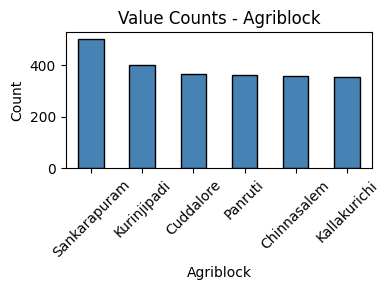

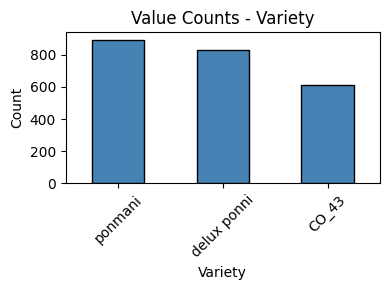

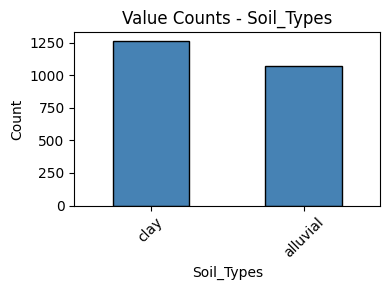

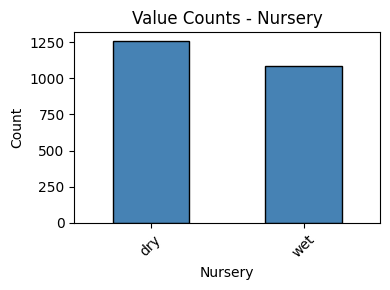

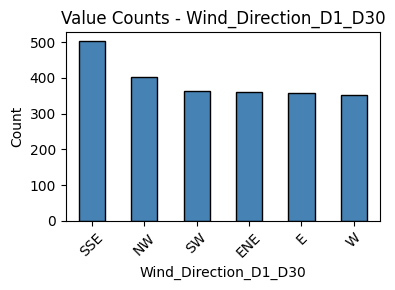

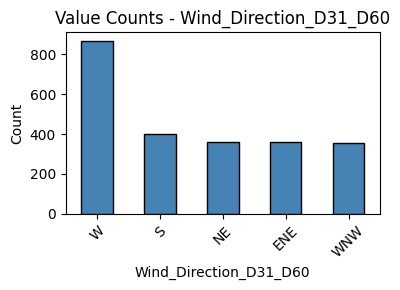

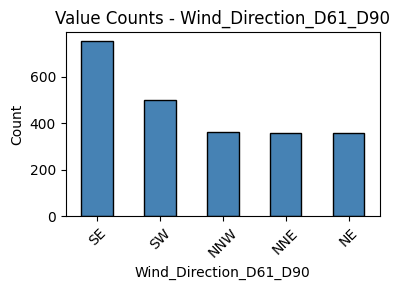

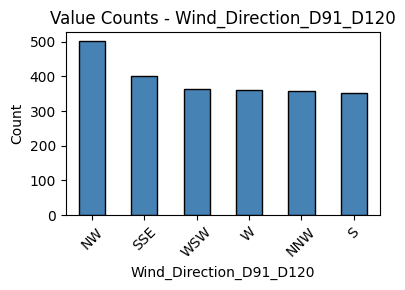

In [16]:
# Categorical Column Value Counts
for col in cat_cols:
    plt.figure(figsize=(4,3))
    df[col].value_counts().plot(kind='bar', color='steelblue', edgecolor='black')
    plt.title(f"Value Counts - {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Correlation Heatmap
- Through this we will understand how strongly features are related to each other and to the target variable (analyze relationships between features) and identify multicollinearity. Highly correlated features (>0.9) were removed to improve model stability.

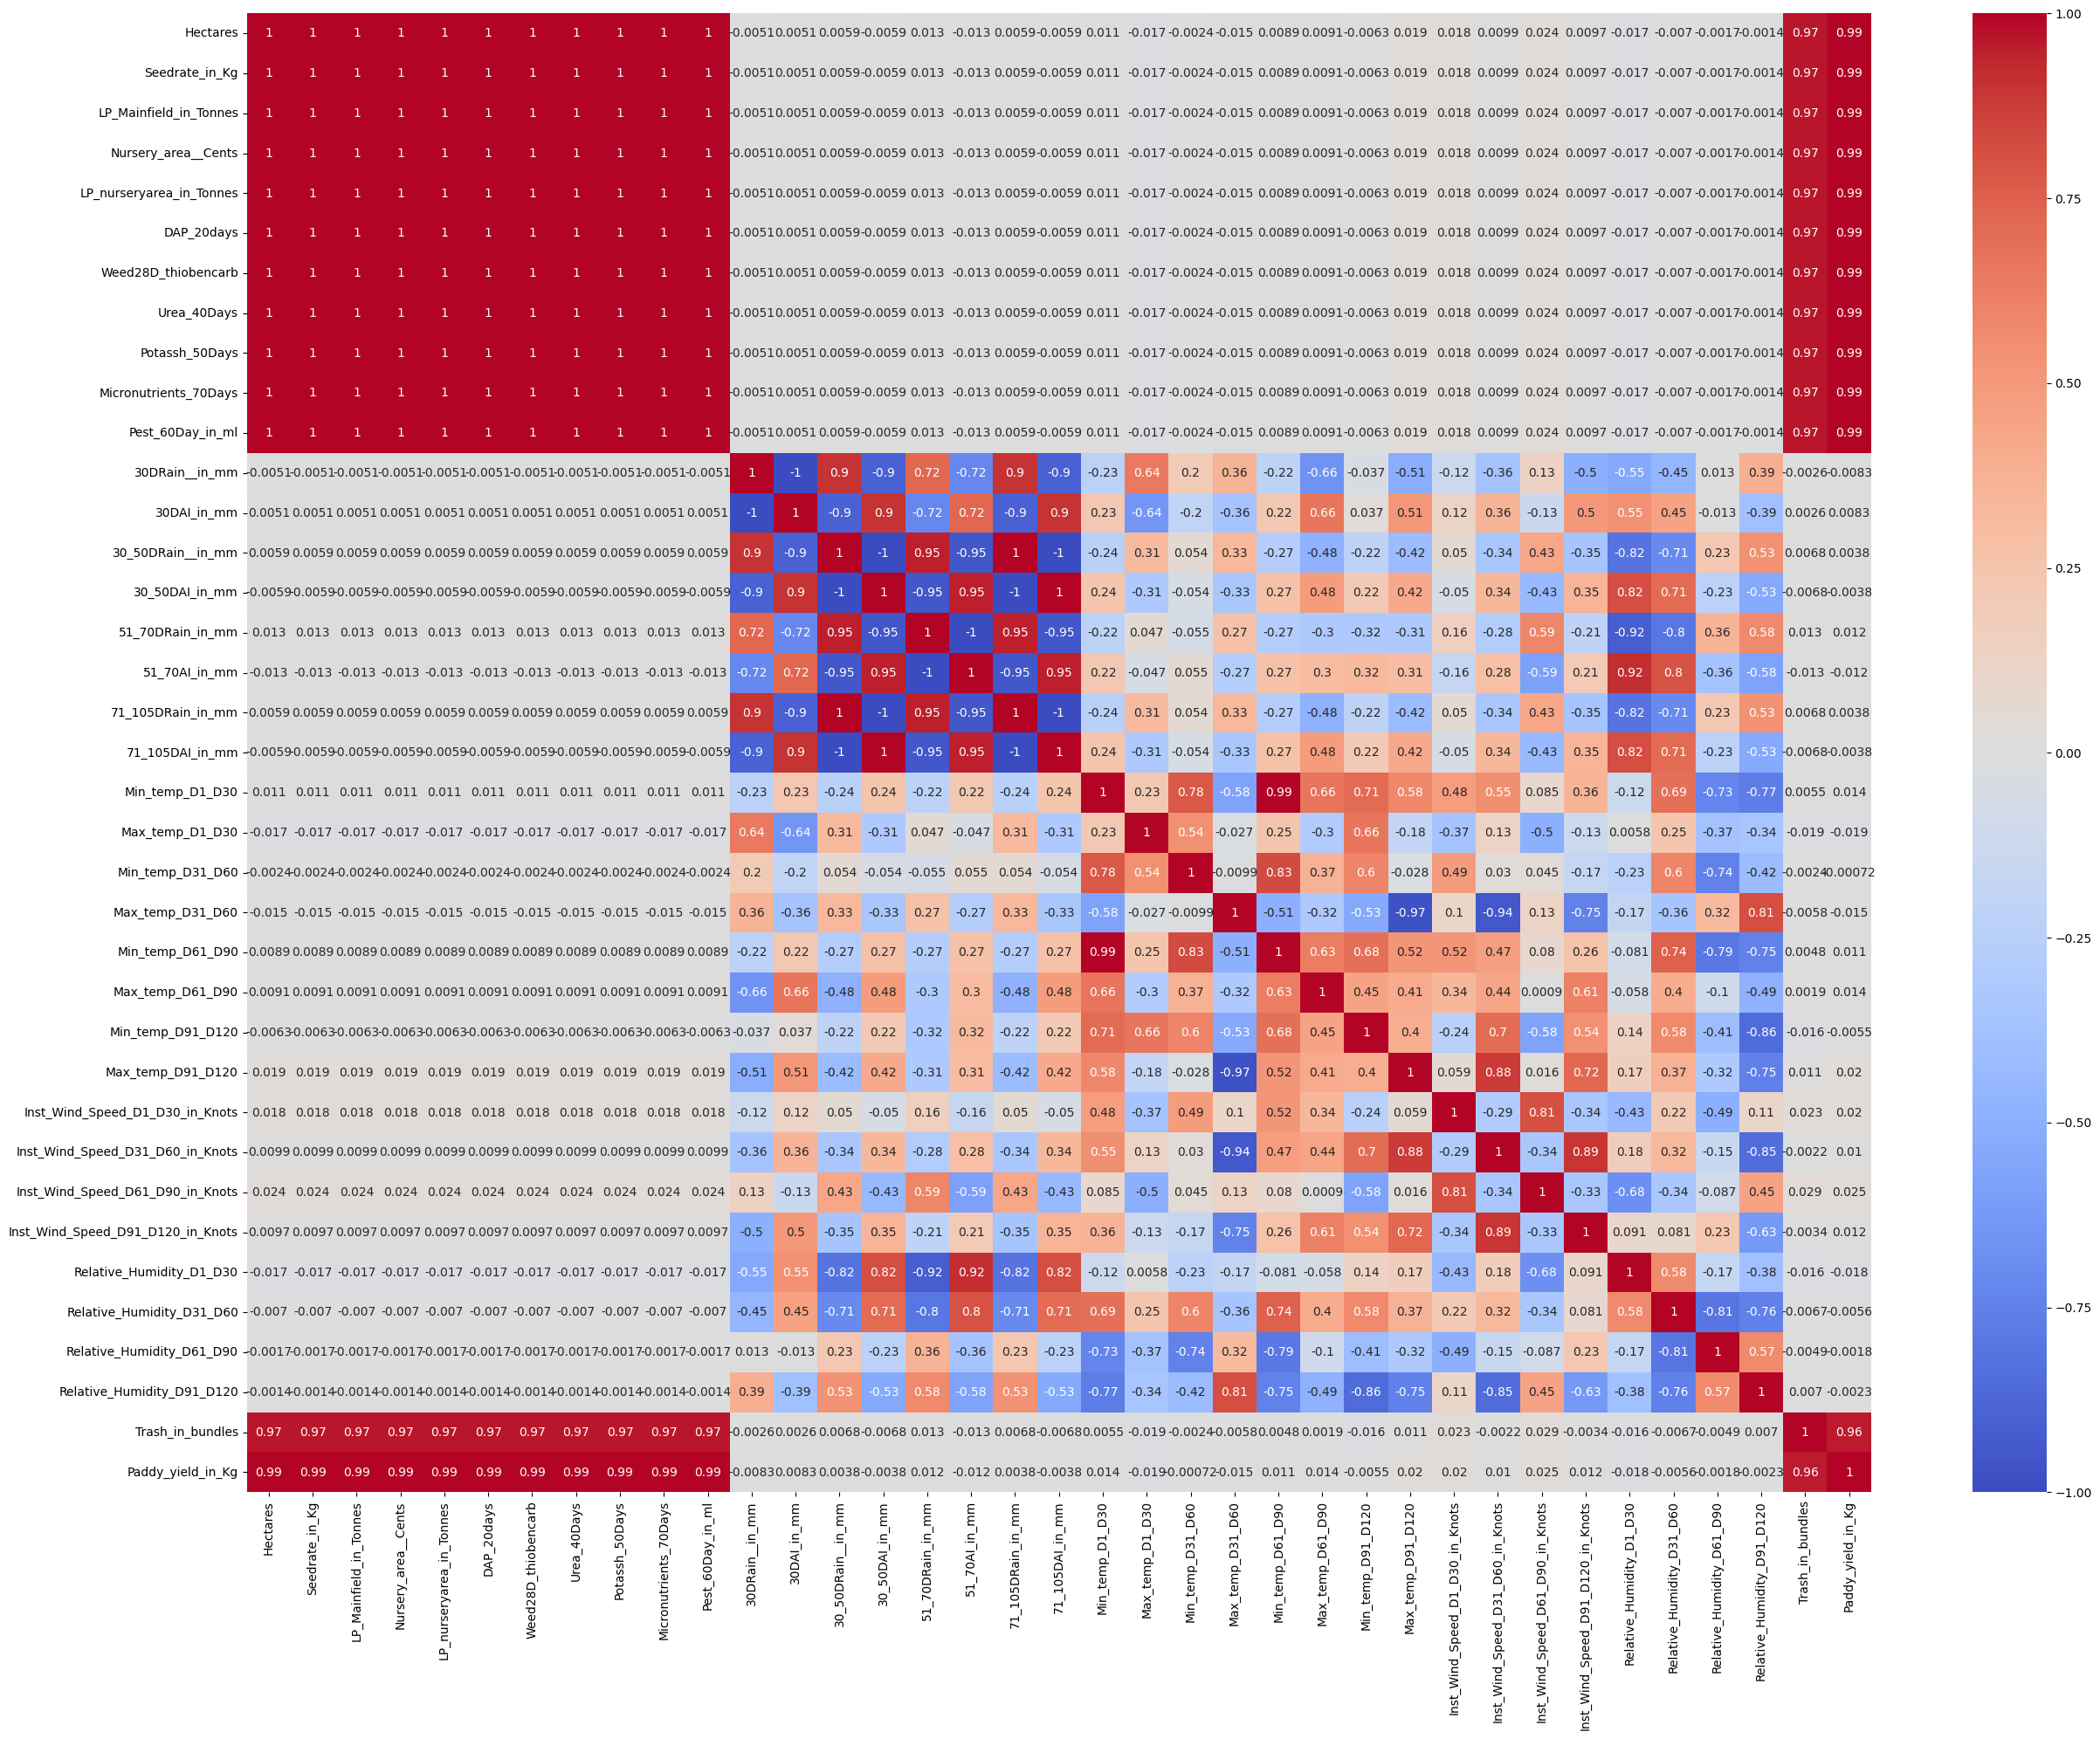

In [17]:
plt.figure(figsize=(30,22))

numeric_df = df.select_dtypes(include=['int64','float64'])

sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")

plt.show()

**Interpretation:**
- The top-left block (dark red) shows **very high correlation (>0.9)** among 
  fertilizer-related features like LP_Mainfield, LP_nurseryarea, Nursery_area, 
  DAP_20days — these were dropped to remove multicollinearity.
- Weather features (rainfall, temperature, wind, humidity) across the 4 intervals 
  show **moderate correlations** with each other — expected since weather 
  patterns persist across growing stages.
- `Hectares` shows a **strong positive correlation with Paddy_yield_in_Kg** — 
  confirming it is the most important predictor.
- Most weather features show **weak to moderate correlation with yield** — 
  meaning no single weather variable dominates; their combined effect matters.
- Blue cells (negative correlation) are minimal — very few features 
  negatively impact yield.

In [18]:
cols_to_drop = [
'LP_Mainfield_in_Tonnes',
'LP_nurseryarea_in_Tonnes',
'Nursery_area__Cents',
'DAP_20days',
'Weed28D_thiobencarb',
'Micronutrients_70Days'
]

df = df.drop(columns=cols_to_drop)

- To improve model stability and reduce redundancy, highly correlated 
duplicate variables were removed while retaining the most relevant 
agricultural features such as Hectares, Seedrate_in_Kg, Urea_40Days, 
Potash_50Days, Pest_60Day_in_ml, and Trash_in_bundles.

- Weather-related variables (rainfall, temperature, wind speed, and humidity) 
were retained because they provide important environmental information 
affecting paddy yield.

# Scatter Plot
-Shows linear or nonlinear relationship between feature and yield.
- Example: **Rainfall vs Yield**

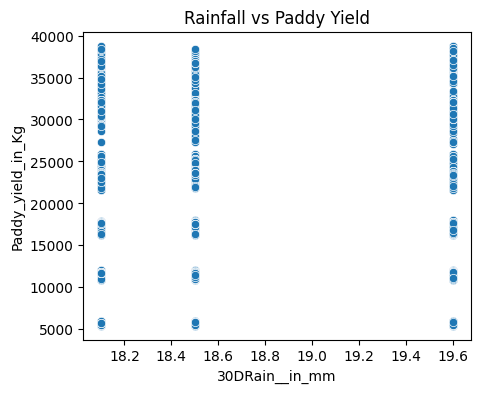

In [19]:
plt.figure(figsize = (5,4))
sns.scatterplot(x = df['30DRain__in_mm'], y = df['Paddy_yield_in_Kg'])
plt.title("Rainfall vs Paddy Yield")
plt.show()
          

**Interpretation:**
**Scatter Plot — Rainfall vs Paddy Yield:**
- Rainfall values are clustered in a narrow range (18.2–19.6 mm), 
  showing very little variation across records.
- Yield varies widely for the same rainfall value — vertical scatter pattern 
  confirms rainfall alone is **not a reliable predictor** of yield.
- This suggests rainfall in this dataset is fairly uniform across farms, 
  and other factors drive yield differences.

# Regression Plot (Shows Trend Line)

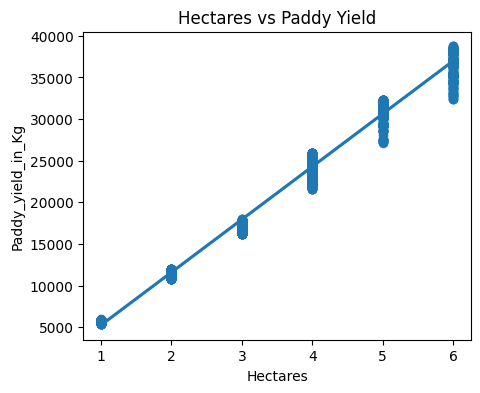

In [20]:
plt.figure(figsize = (5,4))
sns.regplot(x=df['Hectares'], y=df['Paddy_yield_in_Kg'])
plt.title("Hectares vs Paddy Yield")
plt.show()

**Interpretation:**   **Regression Plot — Hectares vs Paddy Yield:**
- A **strong positive linear relationship** is clearly visible - as cultivated 
  area increases from 1 to 6 hectares, yield increases proportionally.
- The trend line fits the data very tightly with minimal spread - 
  confirming `Hectares` is the **strongest single predictor** of paddy yield.
- This makes intuitive sense: more land cultivated = more total crop produced.

# Box Plot (Categorical vs Target)
- Best for categorical features.
- Example:
    - Soil Type vs Yield
    - Variety vs Yield
    - Agriblock vs Yield


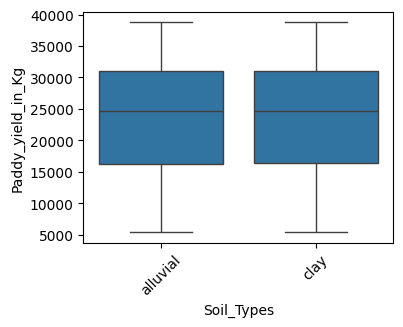

In [21]:
plt.figure(figsize = (4,3))
sns.boxplot(x=df['Soil_Types'], y=df['Paddy_yield_in_Kg'])
plt.xticks(rotation=45)
plt.show()

- **Interpretation :**  **Boxplot — Soil Type vs Paddy Yield:**
- Both `alluvial` and `clay` soils show **similar yield distributions** with 
  overlapping IQR ranges (20,000–30,000 Kg).
- Alluvial soil shows a slightly higher median yield — alluvial soil is 
  generally more fertile and water-retentive, which supports paddy growth.
- Both soil types have wide whiskers — yield varies considerably within 
  each soil type, meaning other factors like fertilizers and weather 
  also play a significant role.

# Violin Plot (Better Distribution View)
- Shows distribution + density.

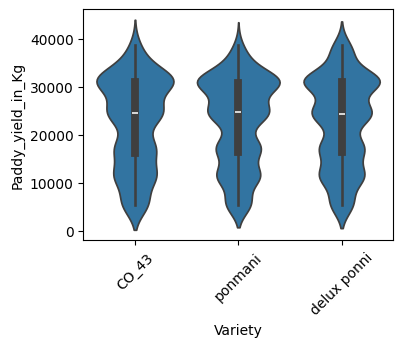

In [22]:
plt.figure(figsize = (4,3))
sns.violinplot(x=df['Variety'], y=df['Paddy_yield_in_Kg'])
plt.xticks(rotation=45)
plt.show()

- **Interpretation :** **Violin Plot — Variety vs Paddy Yield:**
- All three varieties (CO_43, ponmani, delux ponni) show **similar yield 
  distributions** with comparable median values.
- CO_43 appears slightly wider in the middle range — indicating more 
  consistent mid-range yield across farms.
- All varieties have yields concentrated between 15,000–35,000 Kg 
  with similar spread — variety alone does not dramatically 
  differentiate yield outcomes.

# Pair Plot

<Figure size 400x300 with 0 Axes>

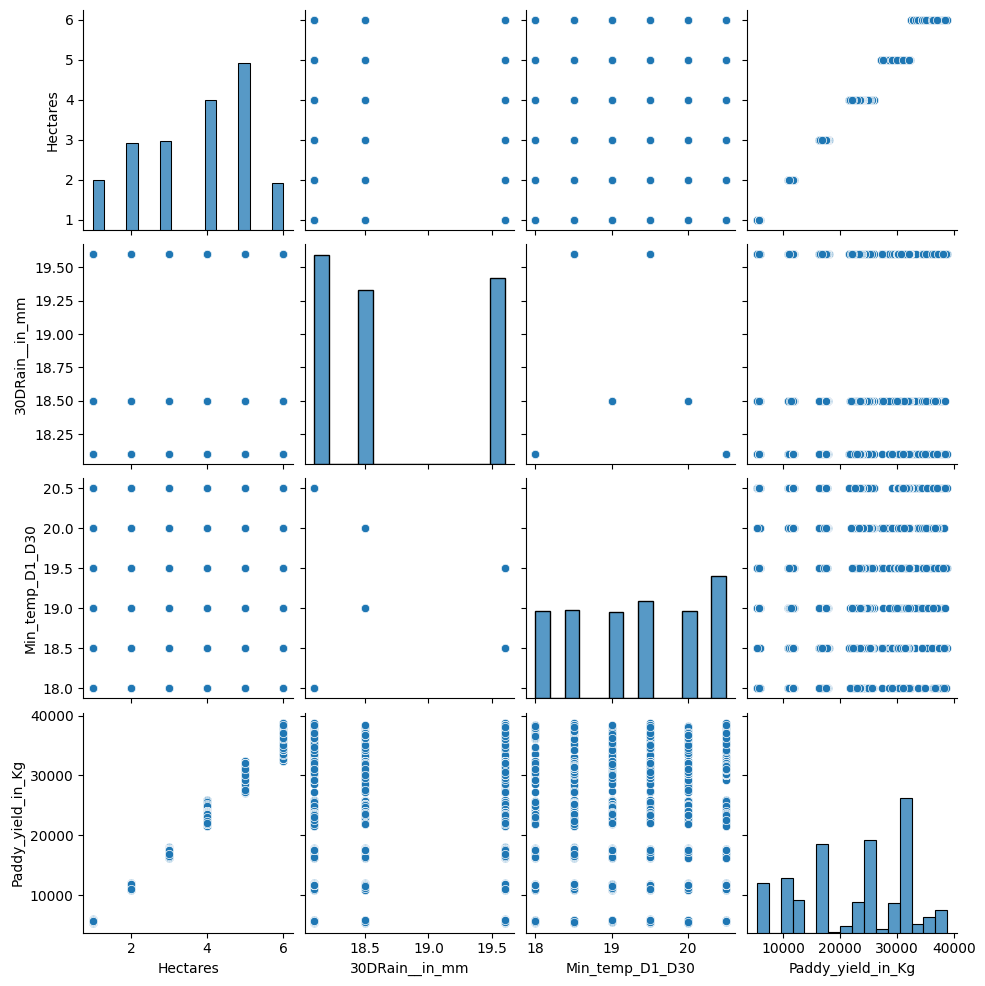

In [23]:
plt.figure(figsize = (4,3))
sns.pairplot(df[['Hectares','30DRain__in_mm','Min_temp_D1_D30','Paddy_yield_in_Kg']])
plt.show()

**Interpretation:**
- **Hectares vs Yield** (bottom-left): Clear positive relationship — 
  larger farms produce more yield, confirming the regplot finding.
- **Rainfall vs Yield** (second column, last row): Points form vertical 
  clusters — rainfall has very limited range and no clear trend with yield.
- **Min Temperature vs Yield** (third column, last row): Scattered pattern 
  with no clear linear trend — temperature alone does not drive yield.
- **Rainfall vs Hectares**: No relationship — farm size and rainfall 
  are independent of each other, as expected.
- **Diagonal histograms**: Hectares is discrete (1–6), Rainfall and 
  Min Temperature are continuous but have limited range — 
  consistent with the skewness chart observations.
- Overall: Among these 4 features, **Hectares is the only one 
  with a clear direct relationship to yield**.

# Selecting Target Variable and Predictors

In [24]:
y = df['Paddy_yield_in_Kg']
print(y.shape)

(2338,)


In [25]:
X = df.drop(columns = ["Paddy_yield_in_Kg"],axis = 1)
print(X.shape)

(2338, 38)


# Train - Test Split

In [26]:
from sklearn.model_selection import train_test_split
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size = 0.2,random_state = 42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1870, 38)
(468, 38)
(1870,)
(468,)


# Handling Outliers 

In [27]:
num_cols = X.select_dtypes(include = ['int64','float64']).columns

In [28]:
for col in num_cols:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_limit = Q1 - 1.5*IQR
    upper_limit = Q3 + 1.5*IQR
    
    X_train[col] = X_train[col].clip(lower_limit, upper_limit)
    X_test[col] = X_test[col].clip(lower_limit, upper_limit)  # apply same limits
    outliers = df[(df[col] < lower_limit) | (df[col] > upper_limit)]
    print(f"{col} outliers count:",outliers.shape[0])

Hectares outliers count: 0
Seedrate_in_Kg outliers count: 0
Urea_40Days outliers count: 0
Potassh_50Days outliers count: 0
Pest_60Day_in_ml outliers count: 0
30DRain__in_mm outliers count: 0
30DAI_in_mm outliers count: 0
30_50DRain__in_mm outliers count: 0
30_50DAI_in_mm outliers count: 0
51_70DRain_in_mm outliers count: 0
51_70AI_in_mm outliers count: 0
71_105DRain_in_mm outliers count: 0
71_105DAI_in_mm outliers count: 0
Min_temp_D1_D30 outliers count: 0
Max_temp_D1_D30 outliers count: 0
Min_temp_D31_D60 outliers count: 0
Max_temp_D31_D60 outliers count: 0
Min_temp_D61_D90 outliers count: 0
Max_temp_D61_D90 outliers count: 0
Min_temp_D91_D120 outliers count: 0
Max_temp_D91_D120 outliers count: 0
Inst_Wind_Speed_D1_D30_in_Knots outliers count: 0
Inst_Wind_Speed_D31_D60_in_Knots outliers count: 0
Inst_Wind_Speed_D61_D90_in_Knots outliers count: 360
Inst_Wind_Speed_D91_D120_in_Knots outliers count: 0
Relative_Humidity_D1_D30 outliers count: 0
Relative_Humidity_D31_D60 outliers count: 0


# checking Unique categories in categorical columns

In [29]:
cat_cols =  X.select_dtypes(include = ['object']).columns

In [30]:
for col in cat_cols:
    print(f"{col} unique values count:",df[col].nunique(),
          
          "- unique values:",df[col].unique())
    

Agriblock unique values count: 6 - unique values: ['Cuddalore' 'Kurinjipadi' 'Panruti' 'Kallakurichi' 'Sankarapuram'
 'Chinnasalem']
Variety unique values count: 3 - unique values: ['CO_43' 'ponmani' 'delux ponni']
Soil_Types unique values count: 2 - unique values: ['alluvial' 'clay']
Nursery unique values count: 2 - unique values: ['dry' 'wet']
Wind_Direction_D1_D30 unique values count: 6 - unique values: ['SW' 'NW' 'ENE' 'W' 'SSE' 'E']
Wind_Direction_D31_D60 unique values count: 5 - unique values: ['W' 'S' 'NE' 'WNW' 'ENE']
Wind_Direction_D61_D90 unique values count: 5 - unique values: ['NNW' 'SE' 'NNE' 'SW' 'NE']
Wind_Direction_D91_D120 unique values count: 6 - unique values: ['WSW' 'SSE' 'W' 'S' 'NW' 'NNW']


# Encoding And Scaling using Column Transformer

In [31]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder , StandardScaler

preprocessor = ColumnTransformer(transformers=[("num",StandardScaler(),num_cols),
                                               ("cat",OneHotEncoder(drop = 'first', sparse_output=False),cat_cols) ])
                                              

# 1.Create Base Pipeline
- pipeline Structure
    - Preprocessing
    → Feature Selection
    → Model

In [33]:
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_regression 

from sklearn.neighbors import KNeighborsRegressor
pipe = Pipeline(steps =[('preprocessing',preprocessor),
                                ('feature_selection', SelectKBest(score_func=f_regression)),
                                ('model',KNeighborsRegressor()) ])

Pipeline structure is fixed at creation
👉 GridSearch can only MODIFY existing steps
👉 It cannot create new steps

# Define Models and Hyperparameters
- Create dictionary of models.

In [34]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor

In [35]:
models = {

"LinearRegression": LinearRegression(),

"Ridge": Ridge(),

"Lasso": Lasso(),

"DecisionTree": DecisionTreeRegressor(),

"RandomForest": RandomForestRegressor(),

"GradientBoosting": GradientBoostingRegressor(),

"KNN": KNeighborsRegressor(),

"SVR": SVR(),

"XGBoost": XGBRegressor(objective='reg:squarederror')
}

# Create Param Grid (All Models)

- GridSearchCV expects: estimator = ONE model
- so we should not pass estimator = dictionary of models like ->   {"KNN": knn_pipeline, "Decision Tree": dt_pipeline, "Naive Bayes": nb_pipeline}

In [36]:
param_grids = {

"LinearRegression": {
"feature_selection__k":[10,15,20]
},

"Ridge": {
"feature_selection__k":[10,15,20],
"model__alpha":[0.01,0.1,1,10]
},

"Lasso": {
"feature_selection__k":[10,15,20],
"model__alpha":[0.001,0.01,0.1,1]
},

"DecisionTree": {
"feature_selection__k":[10,15,20],
"model__max_depth":[5,10,20],
"model__min_samples_split":[2,5,10]
},

"RandomForest": {
"feature_selection__k":[10,15,20],
"model__n_estimators":[100,200],
"model__max_depth":[5,10,20]
},

"GradientBoosting": {
"feature_selection__k":[10,15,20],
"model__n_estimators":[100,200],
"model__learning_rate":[0.01,0.1]
},

"KNN": {
"feature_selection__k":[10,15,20],
"model__n_neighbors":[3,5,7]
},

"SVR": {
"feature_selection__k":[10,15,20],
"model__C":[0.1,1,10],
"model__kernel":["linear","rbf"]
},

"XGBoost": {
"feature_selection__k":[10,15,20],
"model__n_estimators":[100,200],
"model__max_depth":[3,6],
"model__learning_rate":[0.01,0.1]
}
}

# Train All Models with GridSearchCV

In [39]:
from sklearn.model_selection import GridSearchCV
best_models = {}

for name, model in models.items():

    print("Training:", name)

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("feature_selection", SelectKBest(score_func=f_regression)),
        ("model", model)
    ])

    grid = GridSearchCV(
        pipeline,
        param_grids[name],
        cv=5,
        scoring="r2",
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    best_models[name] = grid.best_estimator_

    print("Best Params:", grid.best_params_)
    print("Best CV R2:", grid.best_score_)
    

Training: LinearRegression
Best Params: {'feature_selection__k': 10}
Best CV R2: 0.9891892517682793
Training: Ridge
Best Params: {'feature_selection__k': 10, 'model__alpha': 0.01}
Best CV R2: 0.9891892369278358
Training: Lasso
Best Params: {'feature_selection__k': 10, 'model__alpha': 1}
Best CV R2: 0.9891941487858575
Training: DecisionTree
Best Params: {'feature_selection__k': 10, 'model__max_depth': 5, 'model__min_samples_split': 5}
Best CV R2: 0.9916295596371578
Training: RandomForest
Best Params: {'feature_selection__k': 10, 'model__max_depth': 5, 'model__n_estimators': 100}
Best CV R2: 0.9917217559488366
Training: GradientBoosting
Best Params: {'feature_selection__k': 10, 'model__learning_rate': 0.1, 'model__n_estimators': 100}
Best CV R2: 0.9917705015924427
Training: KNN
Best Params: {'feature_selection__k': 15, 'model__n_neighbors': 7}
Best CV R2: 0.9909688362379105
Training: SVR
Best Params: {'feature_selection__k': 20, 'model__C': 10, 'model__kernel': 'linear'}
Best CV R2: 0.98

# Evaluate Models

In [40]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
results = {}

for name, model in best_models.items():

    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)

    y_train_pred = model.predict(X_train)
    train_r2 = r2_score(y_train, y_train_pred)
    
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)

    results[name] = r2

    print(name)
    print("Testing R2_Score:", r2)
    print("Training R2_Score:", train_r2)
    print("RMSE:", rmse)
    print("MAE:", mae)
    print()

LinearRegression
Testing R2_Score: 0.9877949770742976
Training R2_Score: 0.9892991046325961
RMSE: 1022.1895506062948
MAE: 763.1856618670595

Ridge
Testing R2_Score: 0.9877949694323003
Training R2_Score: 0.9892991045978943
RMSE: 1022.1898706207946
MAE: 763.1837772522341

Lasso
Testing R2_Score: 0.9877976144634206
Training R2_Score: 0.9892981703359187
RMSE: 1022.0791019297662
MAE: 762.7454155351552

DecisionTree
Testing R2_Score: 0.9902194406260806
Training R2_Score: 0.9921742983037919
RMSE: 915.0482277100053
MAE: 660.1687043267019

RandomForest
Testing R2_Score: 0.9902608682022849
Training R2_Score: 0.9921810412205668
RMSE: 913.1082334824005
MAE: 659.6471860158781

GradientBoosting
Testing R2_Score: 0.9902293436981054
Training R2_Score: 0.9921785658814317
RMSE: 914.5848552613991
MAE: 659.1178662916499

KNN
Testing R2_Score: 0.9890130524329608
Training R2_Score: 0.9912318786377147
RMSE: 969.8412753317785
MAE: 700.689255189255

SVR
Testing R2_Score: 0.9863672525438509
Training R2_Score: 0

# Model Comparison Bar Chart

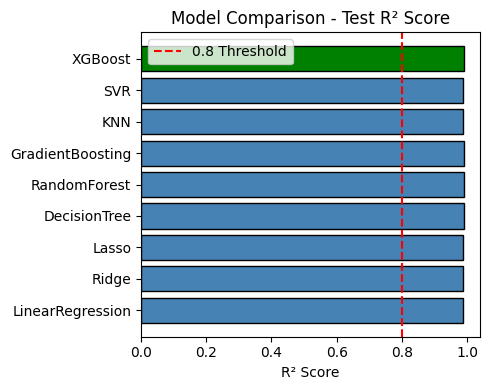

In [41]:
plt.figure(figsize=(5,4))
colors = ['green' if v == max(results.values()) else 'steelblue' for v in results.values()]
plt.barh(list(results.keys()), list(results.values()), color=colors, edgecolor='black')
plt.xlabel("R² Score")
plt.title("Model Comparison - Test R² Score")
plt.axvline(x=0.8, color='red', linestyle='--', label='0.8 Threshold')
plt.legend()
plt.tight_layout()
plt.show()


# Find Best Model

In [42]:
best_model_name = max(results, key=results.get)

print("Best Model:", best_model_name)

Best Model: XGBoost


# Save Best Model

In [43]:
import joblib

best_model = best_models[best_model_name]

joblib.dump(best_model, "paddy_yield_model.pkl")

['paddy_yield_model.pkl']

# Actual vs Predicted Plot

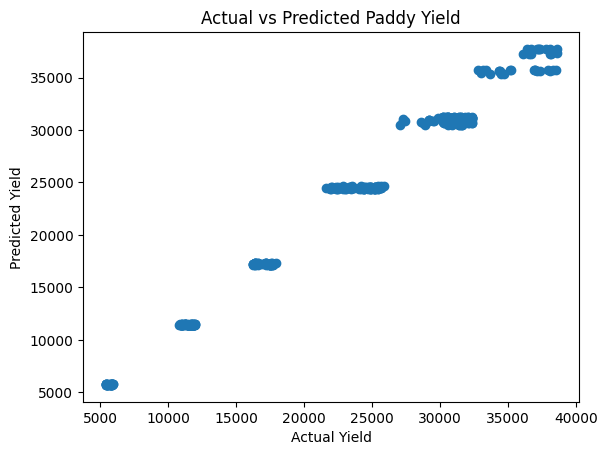

In [44]:
import matplotlib.pyplot as plt
best_model = best_models[best_model_name]
y_pred = best_model.predict(X_test)

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title("Actual vs Predicted Paddy Yield")
plt.show()

In [45]:
# Get feature names after preprocessing
feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()

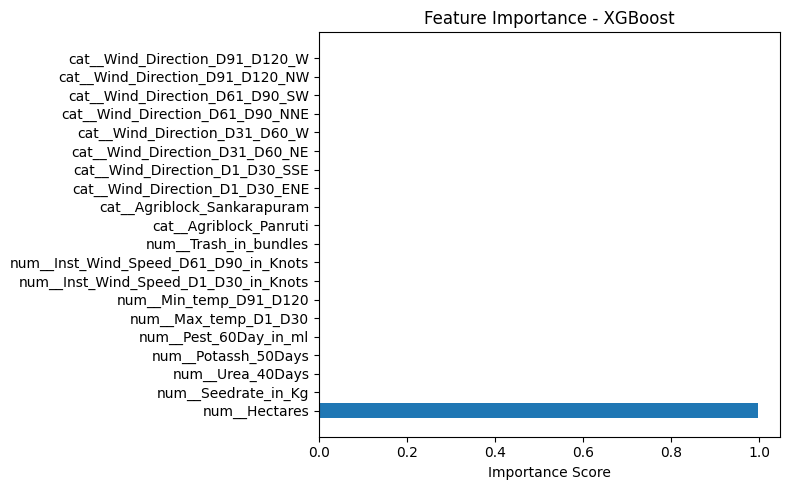

In [46]:
model = best_model.named_steps["model"]

if hasattr(model, "feature_importances_"):
    importance = model.feature_importances_

    # Get the feature names that were selected by SelectKBest
    selected_indices = best_model.named_steps['feature_selection'].get_support(indices=True)
    feature_names_selected = feature_names[selected_indices]

    # Plot with proper labels
    plt.figure(figsize=(8,5))
    plt.barh(feature_names_selected, importance)
    plt.xlabel("Importance Score")
    plt.title("Feature Importance - " + best_model_name)
    plt.tight_layout()
    plt.show()

# Conclusion

## Summary:
- Dataset of paddy cultivation records with agronomic and climatic features was analyzed.
- After cleaning, EDA, outlier handling, and preprocessing, 9 ML models were trained and compared.
- GridSearchCV with 5-fold cross-validation was used for hyperparameter tuning.

## Best Model:
- The best performing model was selected based on highest Test R² Score.
- Model saved as `paddy_yield_model.pkl` for deployment.

## Business Impact:
- This model can help farmers estimate expected paddy yield before harvest.
- Enables better planning of irrigation, fertilizer usage, and resource allocation.
- Can be integrated into agricultural advisory apps or government crop planning systems.